In [4]:
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib as mpl                    
mpl.rc('font', family='Malgun Gothic')      
plt.rcParams['axes.unicode_minus']=False  

import cv2

# PART_03
## 실전문제
- 데이터 캐글
    - 휴대폰 검색어 :  Cracked Mobile Screen Dataset  
    - 표면 검색어 : Surface Crack Detection
- https://www.kaggle.com/datasets/arunrk7/surface-crack-detection/

### 데이터셋 시각화

In [208]:
import os

(227, 227, 3)


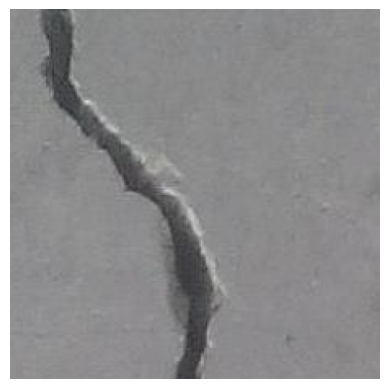

In [212]:
p_img=cv2.imread('./imgs/project/Positive/00007.jpg')
print(p_img.shape)

plt.imshow(cv2.cvtColor(p_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

(227, 227, 3)


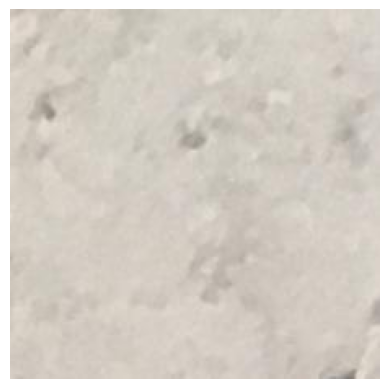

In [18]:
n_img=cv2.imread('./imgs/project/Negative/00002.jpg')
print(n_img.shape)

plt.imshow(cv2.cvtColor(n_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [137]:
positive_dir="./imgs/project/Positive"         # 불량  
negative_dir="./imgs/project/Negative"         # 정상
all_dir=[positive_dir, negative_dir]

In [30]:
positive_len=len(os.listdir(positive_dir))     # 해당 경로에 존재하는 폴더와 파일 리스트(List) 형태 반환
negative_len=len(os.listdir(negative_dir))
all_len=positive_len + negative_len
positive_len, negative_len, all_len

(500, 500, 1000)

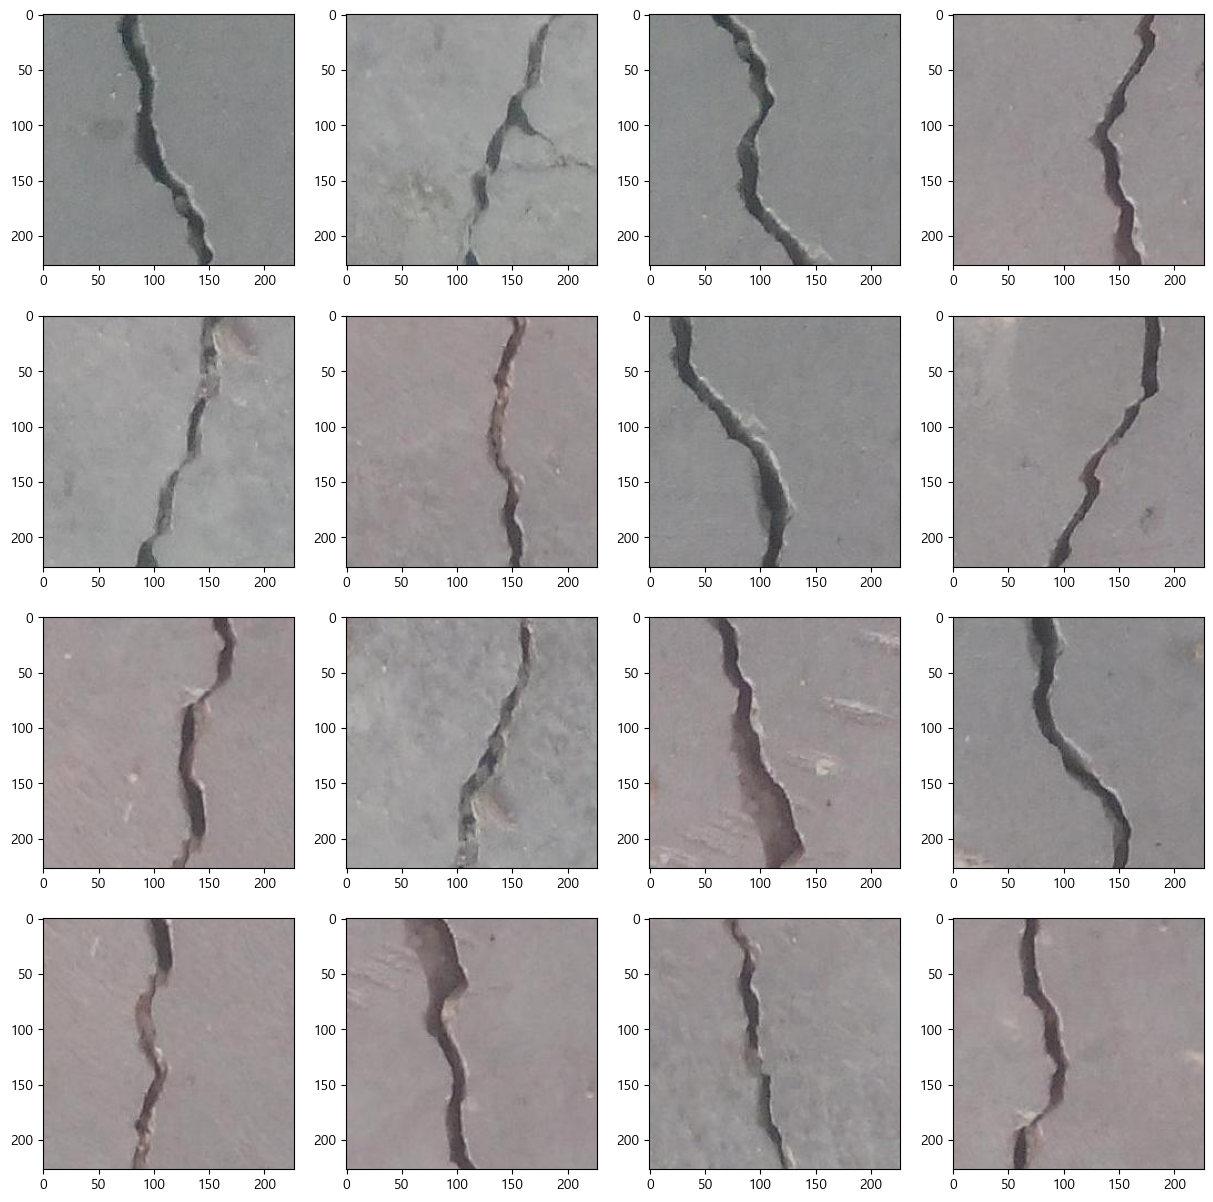

In [34]:
rows=4
cols=4
cnt=0      # 16

fig, axes=plt.subplots(nrows=rows, ncols=cols, figsize=(15, 15))      # 피그, 엑시즈 

for i in range(rows):
    for j in range(cols):
        if cnt < positive_len:
            read=cv2.imread(os.path.join(positive_dir, os.listdir(positive_dir)[cnt]))  
            axes[i, j].imshow(cv2.cvtColor(read, cv2.COLOR_BGR2RGB))
            cnt += 1       

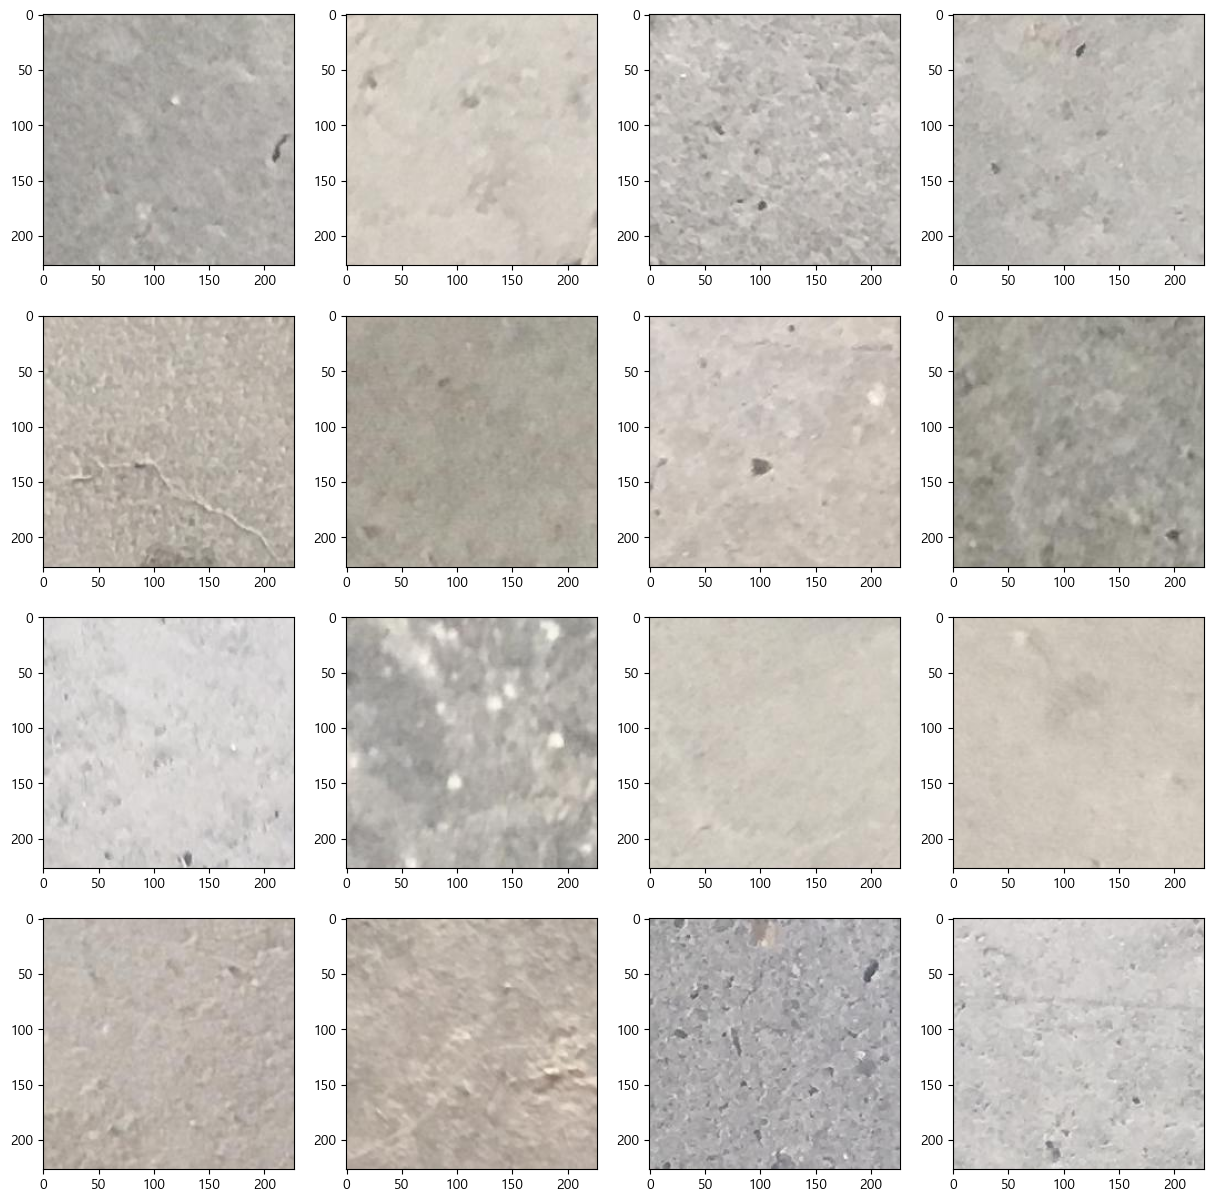

In [39]:
rows=4
cols=4
cnt=0      # 16

fig, axes=plt.subplots(nrows=rows, ncols=cols, figsize=(15, 15))  

for i in range(rows):
    for j in range(cols):
        if cnt < negative_len:
            read=cv2.imread(os.path.join(negative_dir, os.listdir(negative_dir)[cnt]))
            axes[i, j].imshow(cv2.cvtColor(read, cv2.COLOR_BGR2RGB))
            cnt += 1    

### 분류

In [54]:
total=[]
img=[]           # 이미지 List
shapen=[]        # 이미지를 선명하게 만드는 필터, 흐릿한 경계를 강조해서 윤곽선을 더 뚜렷
blurred=[]       # 흐림
gray=[]          # 흑백 
thresh=[]        # 경계선
contours=[]      # 윤곽선

img.append(cv2.imread(os.path.join(positive_dir, os.listdir(positive_dir)[300])))  # 불량
img.append(cv2.imread(os.path.join(positive_dir, os.listdir(positive_dir)[400])))  # 불량 
img.append(cv2.imread(os.path.join(negative_dir, os.listdir(negative_dir)[300])))  # 정상
img.append(cv2.imread(os.path.join(negative_dir, os.listdir(negative_dir)[400])))  # 정상

kernel=np.array([[-1, -1, -1], [-1, 11, -1], [-1, -1, -1]])
for i in range(4):    
    
    # 샤픈 : 대상 이미지, 대상이미지와 동일한 자료형 uint8
    shapen.append(cv2.filter2D(img[i], -1, kernel))   
    
    # 블러  
    blurred.append(cv2.GaussianBlur(shapen[i], (3, 3), 0))   # 블러  

    # 이진화 : 흑백, 경계선
    gray.append(cv2.cvtColor(blurred[i], cv2.COLOR_BGR2GRAY))
    r, thresh_=cv2.threshold(gray[i], 230, 255, cv2.THRESH_BINARY_INV)    # 230 > 255 / 0
    thresh.append(thresh_)

    # 윤곽선
    contours_, h=cv2.findContours(thresh[i], cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

    if contours_:      # 윤곽선이 있니?
        max_len_cnt=max([len(x) for x in contours_])    #  모든 점 중에서 가장 큰 윤곽선의 길이
        contours.append(max_len_cnt)
    else:
        contours.append(0)


total.append(img)
total.append(shapen)
total.append(blurred)
total.append(gray)
total.append(thresh)
total.append(contours)

416
581
0
3


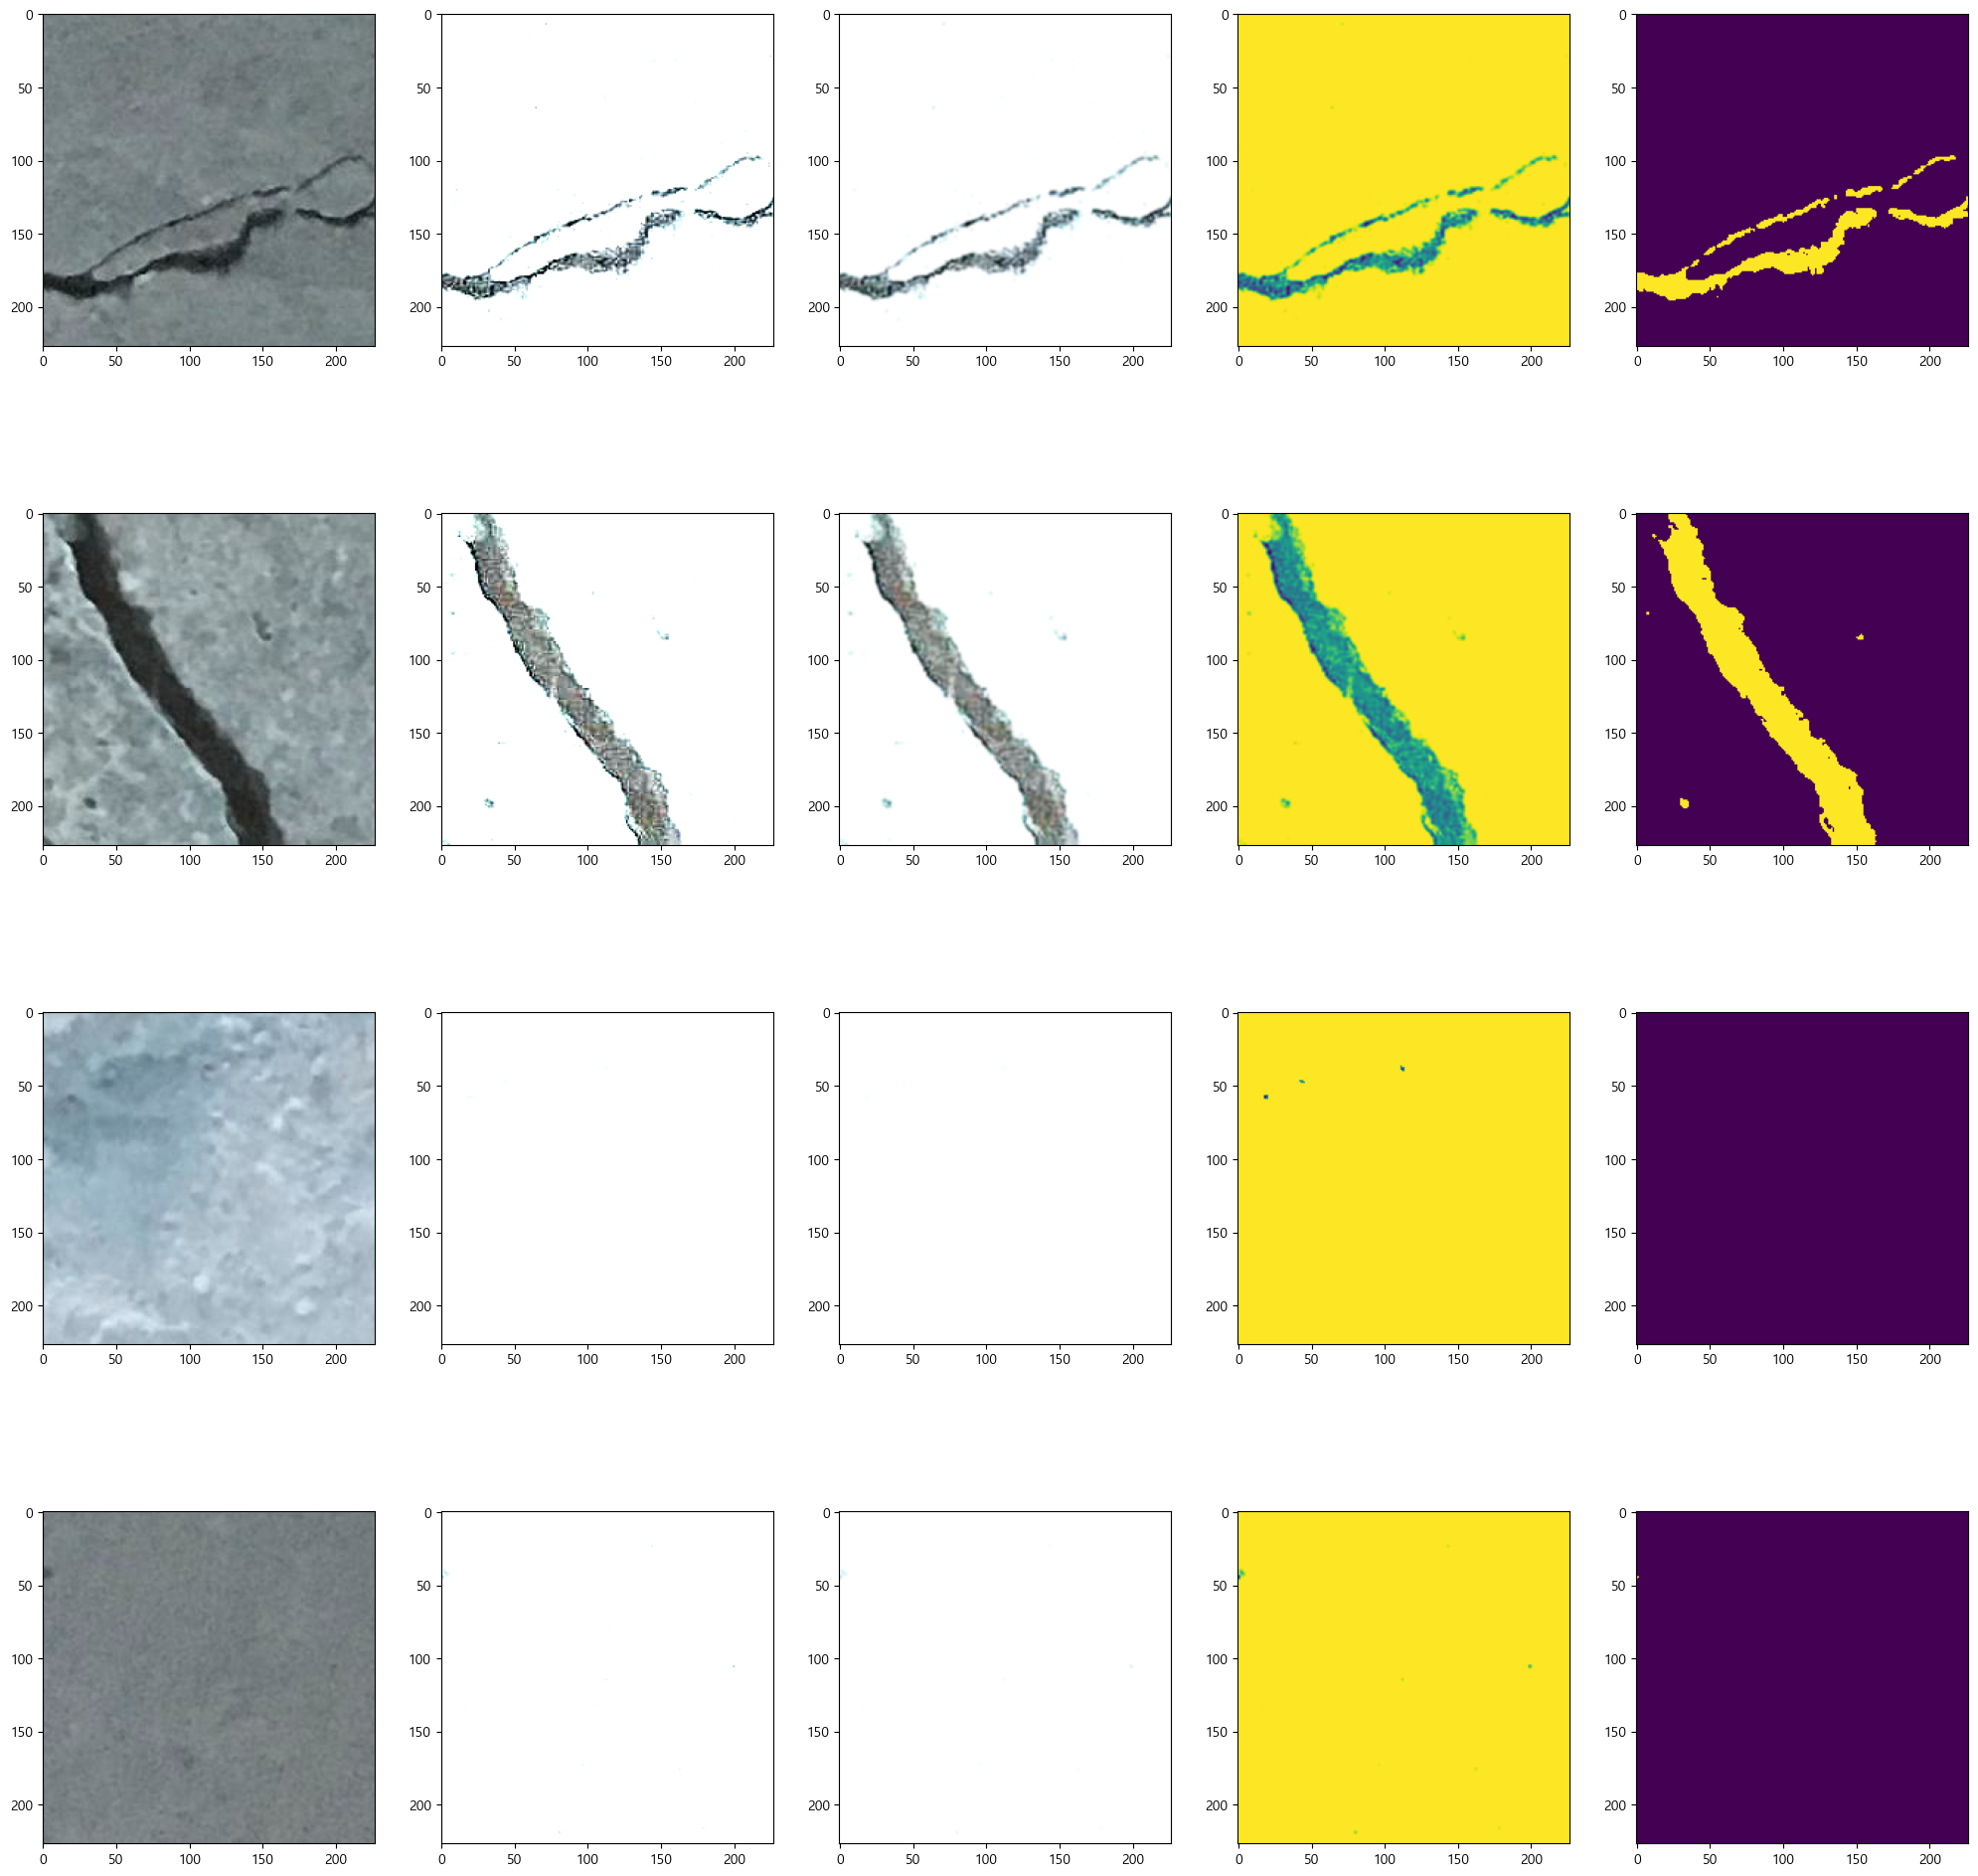

In [65]:
rows=4
cols=5
fig, axes=plt.subplots(nrows=rows, ncols=cols, figsize=(25, 25))

for i in range(rows):   
    print(total[5][i])

    for j in range(cols): 
        # axes[i][j].imshow(cv2.cvtColor(total[j][i], cv2.COLOR_BGR2RGB))   
        axes[i][j].imshow(total[j][i])      # j >> 0: 원본, 1: 샤픈, 2: 블러, ...)

plt.show()

### 결과 분석

In [200]:
def detect_creack (img_name, contour_threshold):
    img=cv2.imread(img_name)

    # 샤픈
    kernel=np.array([[-1, -1, -1], [-1, 11, -1], [-1, -1, -1]])
    shapen=cv2.filter2D(img, -1, kernel)

    # 블러
    blurred=cv2.GaussianBlur(shapen, (3, 3), 0)

    # 이진화
    gray=cv2.cvtColor(blurred, cv2.COLOR_BGR2GRAY)
    r, thresh=cv2.threshold(gray, 230, 255, cv2.THRESH_BINARY_INV)

    # 윤곽선
    contours, h=cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    
    if contours:   # 윤곽선이 있니?
        max_len_cnt=max([len(x) for x in contours])    #  모든 점 중에서 가장 큰 윤곽선의 길이
        
        if max_len_cnt < contour_threshold:    # 균열이 40 ~ 65 작으면 
            return True    # 크랙이 없다. (정상)
        else:
            return False   # 크랙이 있다. (불량)
    else:
        return True        # 크랙이 없다 (정상)

In [202]:
class_result=dict()    # 클래스별(Positive, Negative) 검출 결과를 저장
mintot=1000            # 오분류 수 
lp=0                   
ln=0                   

for contour_threshold in range(40, 65, 5):       # 임계값(Threshold) 루프, 총 5번 반복    

    for classes in all_dir:       # 각 폴더(불량, 정상) 순회
        class_count=0             # 현재 클래스의 crack 검출 개수 초기화
        count=500                 # 최대 500장만 검사
          
        for files in os.listdir(classes):              # 현재 폴더 
            image_name=os.path.join(classes, files)    # 현재 폴더 + 이미지 전체 경로
            
            crack_status=detect_creack(image_name, contour_threshold)   # 해당이미지, 40 50 ~~~

            if crack_status:        # 정상판정된 이미지 개수 
                class_count += 1
          
            count -=1                # 처리 이미지 수 감소
            if count == 0: break     # 500장 검사했으면 종료

        class_result[os.path.basename(classes)]=class_count         # 현재 클래스 결과 저장
        
    
    tot=class_reslut['Positive'] + 500 - class_reslut['Negative']   # FN + FP
    # print(contour_threshold, tot)

    if tot < mintot:     
        mintot=tot                          # 최소 점수 갱신
        lp=500 - class_reslut['Positive']   # 불량을 불량으로 맞춘 개수 
        ln=class_result['Negative']         # 정상을 정상으로 맞춘 개수 
        print(contour_threshold, tot, class_reslut)   

40 13 {'Positive': 11, 'Negative': 498}


In [203]:
print(class_result)     # 불량이미지 500장 중 11개 정상으로(FN), 정상이미지 500장 498 정상으로 올바르게 판단(TN)

{'Positive': 11, 'Negative': 498}


In [204]:
acur=(lp + ln)/1000 * 100
pre=lp / (lp + 500 - ln) * 100
recall=lp / 500 * 100
f1=(2 * pre * recall) / (pre + recall)
print(' 정확도:', acur , '\n 정밀도:', pre, '\n 재현율:', recall, '\n F1 점수:', f1)

 정확도: 97.89999999999999 
 정밀도: 97.99599198396794 
 재현율: 97.8 
 F1 점수: 97.89789789789789


In [ ]:
# End of -------------------------------------------------------------------------------